In [17]:
import pandas as pd
import numpy as np
from sklearn import svm
from sklearn.datasets import load_digits
digits = load_digits()

In [2]:
dir(digits)

['DESCR', 'data', 'feature_names', 'frame', 'images', 'target', 'target_names']

In [4]:
input=pd.DataFrame(digits.data,columns=digits.feature_names)
input

,pixel_0_0,pixel_0_1,pixel_0_2,pixel_0_3,pixel_0_4,pixel_0_5,pixel_0_6,pixel_0_7,pixel_1_0,pixel_1_1,...,pixel_6_6,pixel_6_7,pixel_7_0,pixel_7_1,pixel_7_2,pixel_7_3,pixel_7_4,pixel_7_5,pixel_7_6,pixel_7_7
0,0.0,0.0,5.0,13.0,9.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,6.0,13.0,10.0,0.0,0.0,0.0
1,0.0,0.0,0.0,12.0,13.0,5.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,11.0,16.0,10.0,0.0,0.0
2,0.0,0.0,0.0,4.0,15.0,12.0,0.0,0.0,0.0,0.0,...,5.0,0.0,0.0,0.0,0.0,3.0,11.0,16.0,9.0,0.0
3,0.0,0.0,7.0,15.0,13.0,1.0,0.0,0.0,0.0,8.0,...,9.0,0.0,0.0,0.0,7.0,13.0,13.0,9.0,0.0,0.0
4,0.0,0.0,0.0,1.0,11.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,2.0,16.0,4.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1792,0.0,0.0,4.0,10.0,13.0,6.0,0.0,0.0,0.0,1.0,...,4.0,0.0,0.0,0.0,2.0,14.0,15.0,9.0,0.0,0.0
1793,0.0,0.0,6.0,16.0,13.0,11.0,1.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,6.0,16.0,14.0,6.0,0.0,0.0
1794,0.0,0.0,1.0,11.0,15.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,2.0,9.0,13.0,6.0,0.0,0.0
1795,0.0,0.0,2.0,10.0,7.0,0.0,0.0,0.0,0.0,0.0,...,2.0,0.0,0.0,0.0,5.0,12.0,16.0,12.0,0.0,0.0


In [7]:
target=pd.DataFrame(digits.target)
target

,0
0,0
1,1
2,2
3,3
4,4
...,...
1792,9
1793,0
1794,8
1795,9


In [8]:
from sklearn.model_selection import train_test_split, GridSearchCV

x_train,x_test,y_train,y_test=train_test_split(input,target, test_size=0.2, random_state=10)

In [10]:
from sklearn.neighbors import KNeighborsClassifier
knn=KNeighborsClassifier()
knn.fit(x_train,y_train)

/Users/abhi/miniconda3/lib/python3.13/site-packages/sklearn/neighbors/_classification.py:239: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)


,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [22]:
knn.score(x_test,y_test)

0.9861111111111112

In [23]:
from sklearn.metrics import confusion_matrix
cm=confusion_matrix(y_test,knn.predict(x_test))
len(x_test)

360

Text(58.222222222222214, 0.5, 'Truth')

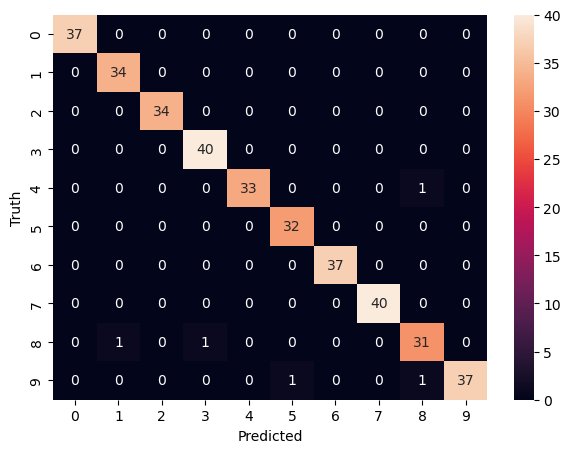

In [24]:
%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sn
plt.figure(figsize=(7,5))
sn.heatmap(cm, annot=True)
plt.xlabel('Predicted')
plt.ylabel('Truth')

Hyper parameter tuning for best K

In [52]:
from sklearn.model_selection import GridSearchCV
gcv=GridSearchCV(KNeighborsClassifier(),{
    'n_neighbors': [1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20]
})
gcv.fit(x_train,y_train)

/Users/abhi/miniconda3/lib/python3.13/site-packages/sklearn/neighbors/_classification.py:239: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)
/Users/abhi/miniconda3/lib/python3.13/site-packages/sklearn/neighbors/_classification.py:239: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)
/Users/abhi/miniconda3/lib/python3.13/site-packages/sklearn/neighbors/_classification.py:239: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)
/Users/abhi/miniconda3/lib/python3.13/site-packages/sklearn/neighbors/_classification.py:239: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Pl

,estimator,KNeighborsClassifier()
,param_grid,"{'n_neighbors': [1, 2, ...]}"
,scoring,None
,n_jobs,None
,refit,True
,cv,None
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_neighbors,1


In [53]:
result=pd.DataFrame(gcv.cv_results_)

In [54]:
result

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_n_neighbors,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
0,0.001292,0.000473,0.007421,0.001650,1,{'n_neighbors': 1},0.993056,0.979167,0.993031,0.982578,0.982578,0.986082,0.005819,1
1,0.000670,0.000046,0.004729,0.000233,2,{'n_neighbors': 2},0.986111,0.979167,0.986063,0.979094,0.972125,0.980512,0.005221,7
2,0.000782,0.000147,0.004845,0.000226,3,{'n_neighbors': 3},0.989583,0.979167,0.986063,0.989547,0.982578,0.985388,0.004049,2
3,0.000648,0.000075,0.005034,0.000574,4,{'n_neighbors': 4},0.989583,0.975694,0.982578,0.986063,0.982578,0.983299,0.004604,4
4,0.000580,0.000027,0.004440,0.000135,5,{'n_neighbors': 5},0.986111,0.982639,0.982578,0.989547,0.982578,0.984691,0.002783,3
5,0.000613,0.000046,0.004683,0.000274,6,{'n_neighbors': 6},0.986111,0.979167,0.979094,0.989547,0.975610,0.981906,0.005121,5
6,0.000634,0.000157,0.004705,0.000420,7,{'n_neighbors': 7},0.986111,0.979167,0.975610,0.989547,0.979094,0.981906,0.005121,5
7,0.000714,0.000060,0.005395,0.000610,8,{'n_neighbors': 8},0.979167,0.975694,0.979094,0.986063,0.968641,0.977732,0.005659,8
8,0.000677,0.000074,0.005195,0.000207,9,{'n_neighbors': 9},0.979167,0.975694,0.975610,0.989547,0.968641,0.977732,0.006826,8
9,0.000667,0.000057,0.005138,0.000178,10,{'n_neighbors': 10},0.979167,0.972222,0.975610,0.982578,0.965157,0.974947,0.005996,10
